Name    : Lathika M
Roll No : 24BAD062
SCENARIO 1 – KNN Breast Cancer Classification
First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280     

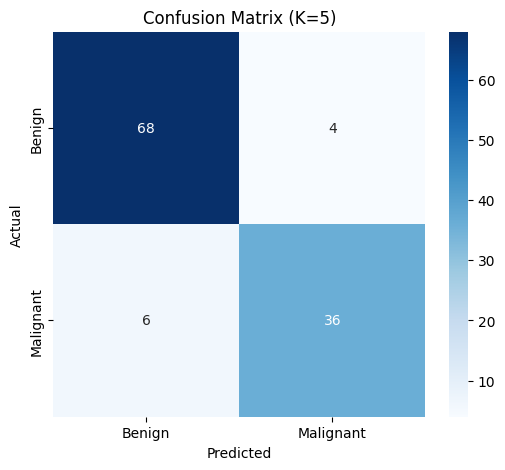


Number of Misclassified Samples: 10


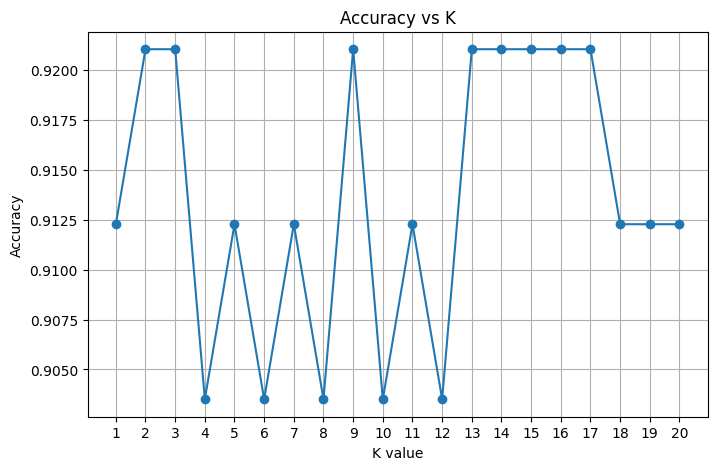

Best K value: 2
Best Accuracy: 0.9210526315789473


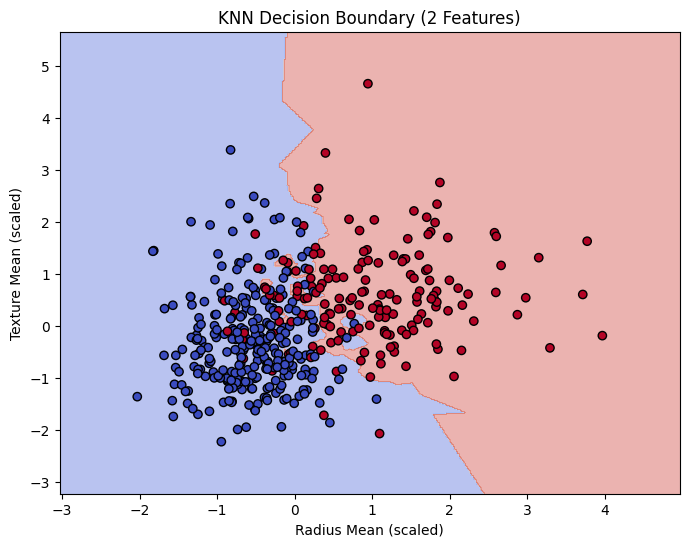

In [11]:
# SCENARIO 1 – KNN Breast Cancer Classification

print("Name    : Lathika M")
print("Roll No : 24BAD062")
print("SCENARIO 1 – KNN Breast Cancer Classification")
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# 2. Load Dataset

df = pd.read_csv('/kaggle/input/datasets/yasserh/breast-cancer-dataset/breast-cancer.csv')

# 3. Data Inspection
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# Drop unnecessary column if exists
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])

if 'id' in df.columns:
    df = df.drop(columns=['id'])

# 4. Encode Target Labels
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  
# Benign = 0, Malignant = 1

# 5. Select Important Features
features = ['radius_mean', 'texture_mean', 'perimeter_mean',
            'area_mean', 'smoothness_mean']

X = df[features]
y = df['diagnosis']

# 6. Feature Scaling (VERY IMPORTANT for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 8. Train KNN Classifier (default K=5)
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# 9. Predictions
y_pred = knn.predict(X_test)

# 10. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance (K=5)")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 11. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (K=5)")
plt.show()

# 12. Identify Misclassified Cases
misclassified = np.where(y_test != y_pred)[0]
print("\nNumber of Misclassified Samples:", len(misclassified))

# 13. Analyze Model Sensitivity to K
k_values = range(1, 21)
accuracy_list = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy_list.append(accuracy_score(y_test, pred))

# Plot Accuracy vs K
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracy_list, marker='o')
plt.title("Accuracy vs K")
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid()
plt.show()

best_k = k_values[np.argmax(accuracy_list)]
print("Best K value:", best_k)
print("Best Accuracy:", max(accuracy_list))


# 14. Decision Boundary (Using 2 Features Only)

X2 = df[['radius_mean', 'texture_mean']]
y2 = df['diagnosis']

X2_scaled = StandardScaler().fit_transform(X2)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_scaled, y2, test_size=0.2, random_state=42, stratify=y2
)

knn2 = KNeighborsClassifier(n_neighbors=best_k)
knn2.fit(X2_train, y2_train)

# Create mesh grid
h = 0.02
x_min, x_max = X2_train[:, 0].min() - 1, X2_train[:, 0].max() + 1
y_min, y_max = X2_train[:, 1].min() - 1, X2_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(X2_train[:, 0], X2_train[:, 1],
            c=y2_train, edgecolor='k', cmap='coolwarm')
plt.title("KNN Decision Boundary (2 Features)")
plt.xlabel("Radius Mean (scaled)")
plt.ylabel("Texture Mean (scaled)")
plt.show()

Available Files:

/kaggle/input/datasets/ninzaami/loan-predication/train_u6lujuX_CVtuZ9i (1).csv
/kaggle/input/datasets/yasserh/breast-cancer-dataset/breast-cancer.csv

First 5 rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141

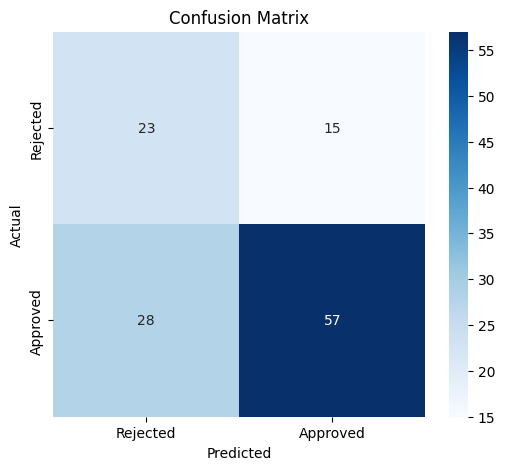

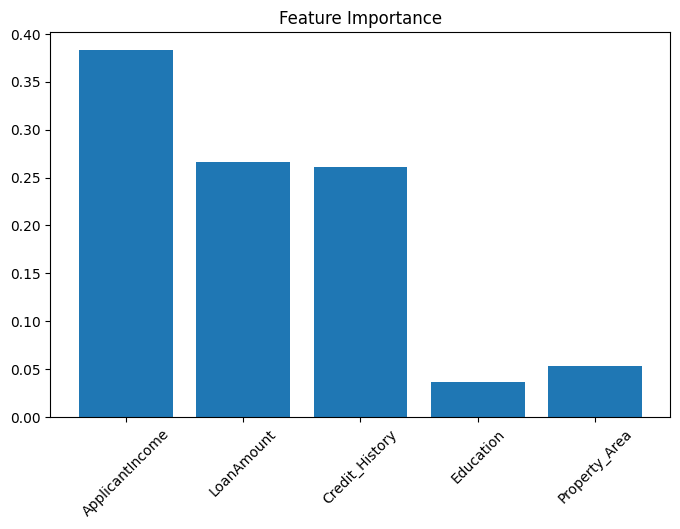


Feature Importance Values:
ApplicantIncome : 0.3826506365405745
LoanAmount : 0.2662984980727558
Credit_History : 0.2614460303711441
Education : 0.036354171979730066
Property_Area : 0.05325066303579564


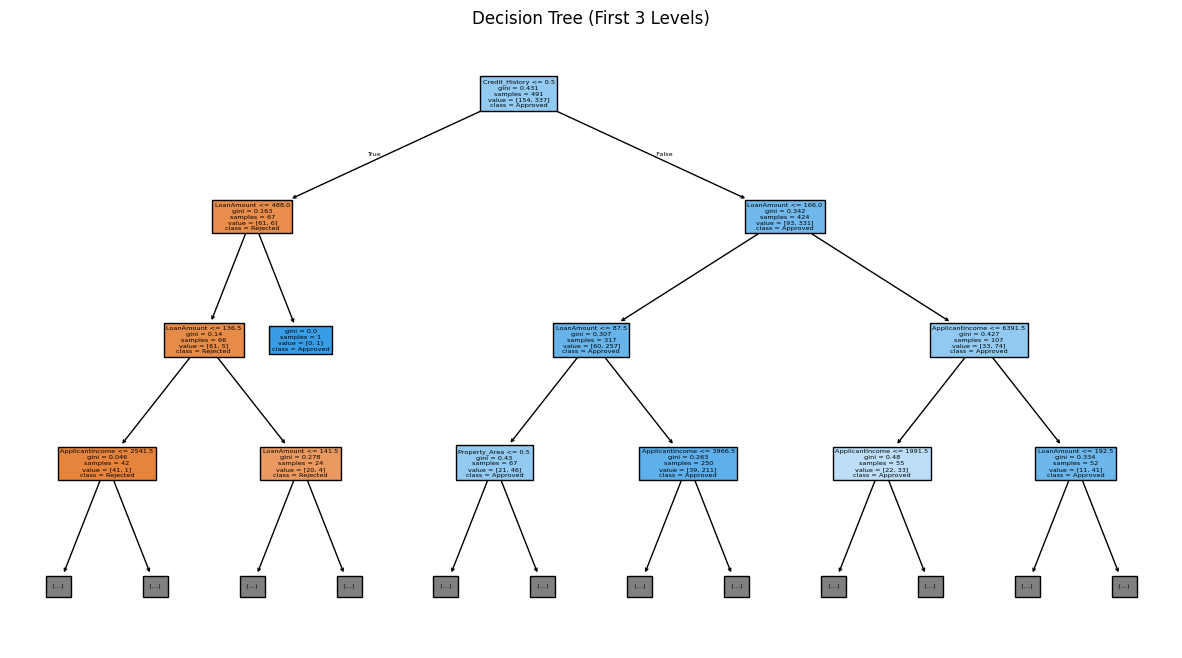


Training Accuracy: 1.0
Testing Accuracy : 0.6504065040650406
⚠ Model may be overfitting.


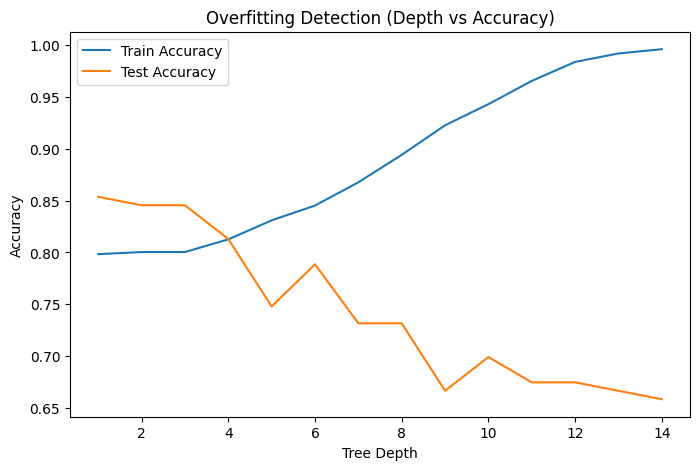

Best Depth: 1
Best Test Accuracy: 0.8536585365853658


In [17]:
# SCENARIO 2 – DECISION TREE CLASSIFIER
print("Name    : Lathika M")
print("Roll No : 24BAD062")
print("SCENARIO 1 – KNN Breast Cancer Classification")
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# 2. Automatically Find Dataset Path (Prevents FileNotFoundError)

print("Available Files:\n")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Use correct filename shown above
df = pd.read_csv('/kaggle/input/datasets/ninzaami/loan-predication/train_u6lujuX_CVtuZ9i (1).csv')

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values Before Handling:")
print(df.isnull().sum())

# 3. Preprocessing (Clean Version – No Warnings)

# Drop Loan_ID if exists
if 'Loan_ID' in df.columns:
    df = df.drop(columns=['Loan_ID'])

# Handle Missing Values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("\nMissing Values After Handling:")
print(df.isnull().sum())

# Select required features
features = ['ApplicantIncome', 'LoanAmount',
            'Credit_History', 'Education', 'Property_Area']

X = df[features].copy()
y = df['Loan_Status'].copy()

# Encode categorical variables
le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

# Encode target
y = le.fit_transform(y)  # Approved=1, Rejected=0

# 4. Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# 5. Train Decision Tree (Deep Tree)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

# 6. Evaluation Metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nDecision Tree Performance (Deep Tree)")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected','Approved'],
            yticklabels=['Rejected','Approved'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 8. Feature Importance

importances = dt.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(X.columns, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

print("\nFeature Importance Values:")
for feature, importance in zip(X.columns, importances):
    print(feature, ":", importance)

# 9. Tree Structure Plot (Limited Depth for Clarity)

plt.figure(figsize=(15,8))
plot_tree(dt,
          feature_names=X.columns,
          class_names=['Rejected','Approved'],
          filled=True,
          max_depth=3)
plt.title("Decision Tree (First 3 Levels)")
plt.show()


# 10. Overfitting Detection


train_acc = dt.score(X_train, y_train)
test_acc = dt.score(X_test, y_test)

print("\nTraining Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)

if train_acc > test_acc:
    print("⚠ Model may be overfitting.")

# 11. Shallow vs Deep Tree Comparison

depths = range(1, 15)
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(8,5))
plt.plot(depths, train_scores, label="Train Accuracy")
plt.plot(depths, test_scores, label="Test Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Detection (Depth vs Accuracy)")
plt.legend()
plt.show()

best_depth = depths[np.argmax(test_scores)]
print("Best Depth:", best_depth)
print("Best Test Accuracy:", max(test_scores))